Now project all cells to the latent space and visualize the results using UMAP.
the scANVI embedding will be thrown away

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import scvi
import anndata as ad

In [3]:
MODEL_DIR = Path.home() / "project/crc-pm/result/scvi/scvi_model"
model_scvi = scvi.model.SCVI.load(MODEL_DIR)
DATA_IN_DIR = Path.home() / "project/crc-pm/result/label-transfer/qc_and_transferred.h5ad"
adata_full = sc.read_h5ad(DATA_IN_DIR)


INFO     File /home/zhekai/project/crc-pm/result/scvi/scvi_model/model.pt already downloaded                       


/home/zhekai/miniconda3/envs/scarches/lib/python3.11/site-packages/scvi/model/base/_base_model.py:869: UserWarning: Save path contains no saved anndata and no adata was passed. Model will be loaded without anndata.
  ) = _load_saved_files(


In [4]:
HVG_gene = pd.read_csv(
    str(Path.home() / "project/crc-pm/result/hvg" / "hvg_flags.tsv"),
      sep="\t",
      index_col="gene_id",
  )
adata_full.var['highly_variable'] = HVG_gene
adata_full.obs["Study_Batch"] = (
      adata_full.obs["Study"].astype(str)
      + "_"
      + adata_full.obs["Batch"].astype(str)
  ).astype("category")

In [5]:
# 删除 KUL3 Border
border = (
    adata_full.obs["Study"].astype(str).eq("crc10-KUL3")
    & adata_full.obs["Sample"].astype(str).str.endswith("-B")
)
adata_full = adata_full[~border].copy()


# 从模型 registry 恢复训练时使用的 HVG 及其顺序
# 模型保存时没有保存 AnnData，因此不能使用 model_scvi.adata.var_names
hvg_genes = pd.Index(model_scvi.get_var_names())

assert hvg_genes.is_unique
assert hvg_genes.isin(adata_full.var_names).all()


# ============================================================
# 1. 直接映射模型训练时见过的 batch
# ============================================================

known_studies = [
    "crc03",
    "crc06",
    "crc09",
    "crc10-KUL3",
    "crc10-SMC",
]

known_mask = (
    adata_full.obs["Study"]
    .astype(str)
    .isin(known_studies)
)

adata_known = adata_full[known_mask].copy()

# 重新生成 category，避免残留 crc01 的未使用 category
adata_known.obs["Study_Batch"] = (
    adata_known.obs["Study"].astype(str)
    + "_"
    + adata_known.obs["Batch"].astype(str)
).astype("category")

adata_known_hvg = adata_known[:, hvg_genes].copy()

latent_known = model_scvi.get_latent_representation(
    adata=adata_known_hvg,
    batch_size=512,
)


# ============================================================
# 2. 将 crc01 作为新 query 映射
# ============================================================

adata_crc01 = adata_full[
    adata_full.obs["Study"].astype(str).eq("crc01")
].copy()

adata_crc01.obs["Study_Batch"] = (
    adata_crc01.obs["Study"].astype(str)
    + "_"
    + adata_crc01.obs["Batch"].astype(str)
).astype("category")

adata_crc01_hvg = adata_crc01[:, hvg_genes].copy()

query_model = scvi.model.SCVI.load_query_data(
    adata=adata_crc01_hvg,
    reference_model=model_scvi,
)

query_model.train(
    max_epochs=100,
    batch_size=512,
    plan_kwargs={"weight_decay": 0.0},
)

latent_crc01 = query_model.get_latent_representation(
    batch_size=512,
)


# ============================================================
# 3. 按 adata_full 原始细胞顺序合并 latent
# ============================================================

latent_full = np.full(
    (adata_full.n_obs, latent_known.shape[1]),
    np.nan,
    dtype=np.float32,
)

known_pos = adata_full.obs_names.get_indexer(
    adata_known.obs_names
)

crc01_pos = adata_full.obs_names.get_indexer(
    adata_crc01.obs_names
)

assert (known_pos >= 0).all()
assert (crc01_pos >= 0).all()

latent_full[known_pos] = latent_known
latent_full[crc01_pos] = latent_crc01

assert np.isfinite(latent_full).all()

adata_full.obsm["X_scVI"] = latent_full

print(adata_full)
print(adata_full.obsm["X_scVI"].shape)

INFO     Model was loaded without AnnData. Setting up provided AnnData using saved registry.                       


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/zhekai/miniconda3/envs/scarches/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_

Training:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


AnnData object with n_obs × n_vars = 333210 × 26179
    obs: 'Sample', 'CellID', 'Tissue', 'Patient', 'Batch', 'OrigCellType', 'Study', 'Glob_CellID', 'Glob_Sample', 'Glob_Patient', 'OrigCellTypeFull', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'qc_outlier', 'predicted_doublet', 'doublet_score', 'CellType', 'Study_Batch'
    var: 'gene_name', 'gene_id', 'gene_biotype', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable'
    uns: 'Study_colors'
    obsm: 'X_scVI'
    layers: 'counts'
(333210, 20)


In [6]:
sc.pp.neighbors(
    adata_full,
    use_rep="X_scVI",
    n_neighbors=50,
    metric="cosine",
    random_state=2026,
)

sc.tl.umap(
    adata_full,
    min_dist=0.3,
    random_state=2026,)

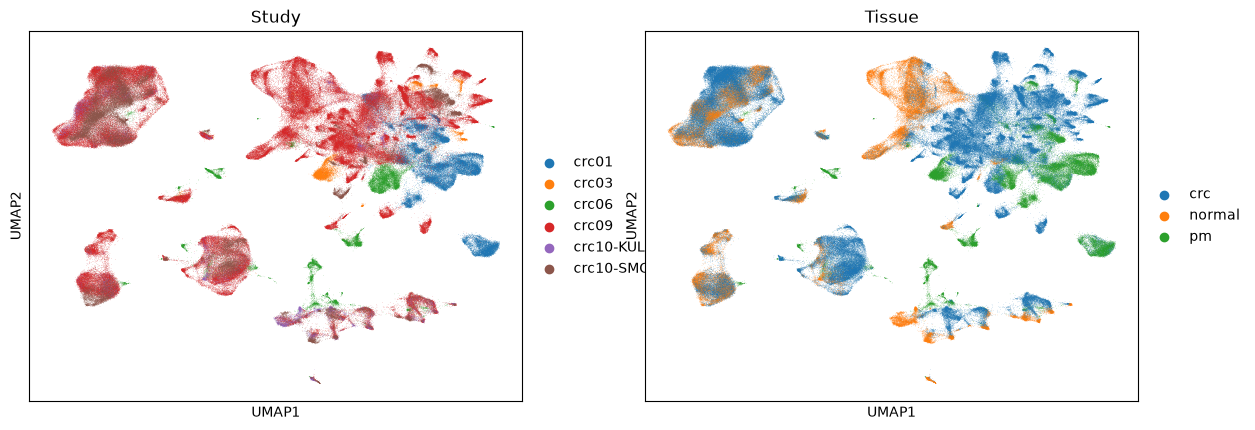

In [7]:
sc.pl.umap(
    adata_full,
    color=[
        "Study",
        "Tissue",
    ],)

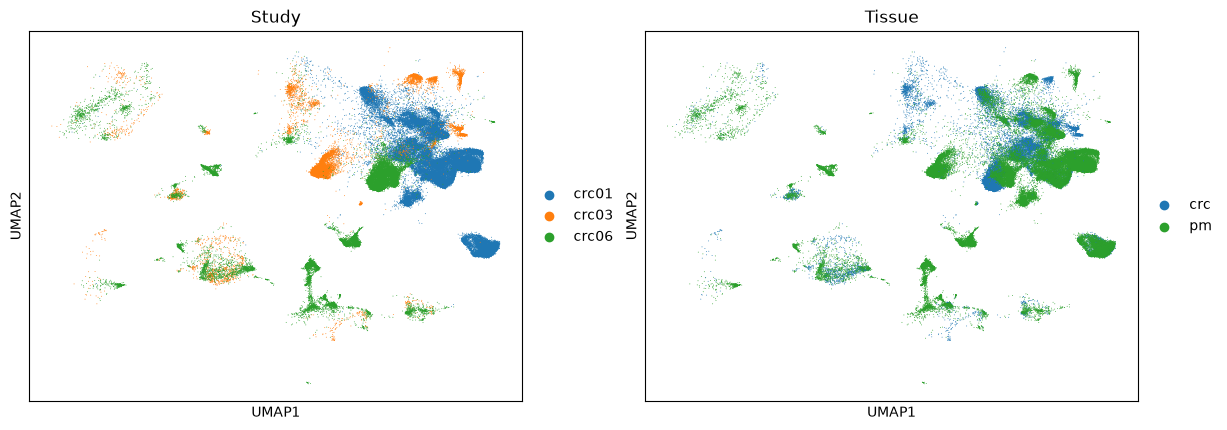

In [8]:
sc.pl.umap(
    adata_full[adata_full.obs['Study'].isin(['crc01','crc03','crc06'])],
    color=[
        "Study",
        "Tissue",
    ],)

### Normalization

In [9]:
adata_full.layers["log1p"] = adata_full.layers["counts"].copy()

sc.pp.normalize_total(
    adata_full,
    target_sum=1e4,
    layer="log1p",
)

sc.pp.log1p(
    adata_full,
    layer="log1p",
)

In [10]:
adata_full.layers["log1p"]

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 739352732 stored elements and shape (333210, 26179)>

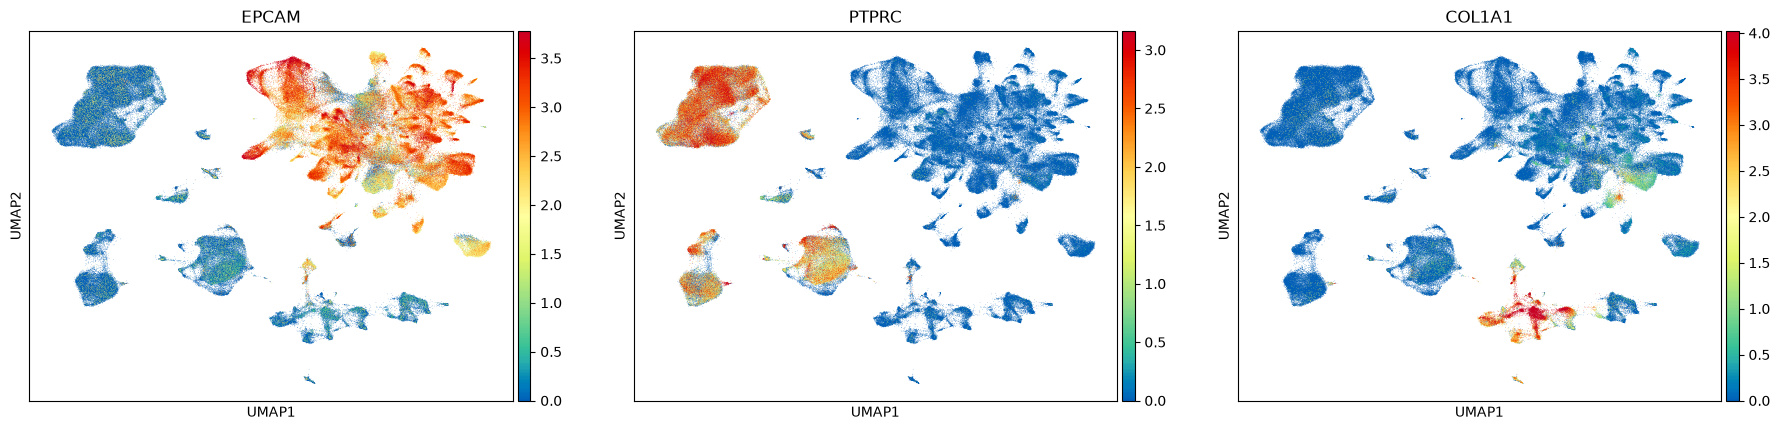

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, rgb_to_hsv, hsv_to_rgb

def saturate_colormap(cmap, saturation=1.4, minval=0.08, maxval=0.92, n=256):
    cmap = plt.get_cmap(cmap)

    colors = cmap(np.linspace(minval, maxval, n))
    rgb = colors[:, :3]

    hsv = rgb_to_hsv(rgb)
    hsv[:, 1] = np.clip(hsv[:, 1] * saturation, 0, 1)

    rgb_sat = hsv_to_rgb(hsv)

    return LinearSegmentedColormap.from_list(
        f"{cmap.name}_sat_{saturation}",
        rgb_sat,
        N=n,
    )

cmap = saturate_colormap(
    "Spectral_r",
    saturation=1.5,
    minval=0.08,
    maxval=0.92,
)
sc.pl.umap(
    adata_full,
    color=["EPCAM", "PTPRC", "COL1A1"],
    gene_symbols="gene_name",
    layer="log1p",
    color_map=cmap,
    vmin="p1",
    vmax="p99",
    size=0.5,
)

In [ ]:
adata_full.write_h5ad(Path.home() / "project/crc-pm/result/dr-anno" / "ready_for_anno.h5ad")

: 